# 🧠 BrainSeg AI v2 — BraTS 2020 Full Pipeline
**All bugs fixed | Dataset visualization | Training | Prediction viewer | Accuracy matrix**

---
| Setting | Value |
|---|---|
| Dataset | `awsaf49/brats2020-dataset-training-validation` |
| Accelerator | GPU T4 x2 |
| Model | 3D U-Net (depth=4, base_filters=16) |
| Input | 4-channel MRI → (128,128,128,4) |
| Classes | Background / NCR-NET / Edema / ET |
| Fixes | ✅ Zero-epoch bug | ✅ Parallel data loading | ✅ Pre-cache | ✅ Mixed precision |

## 0 — Install & Imports

In [1]:
%%capture
!pip install nibabel pydicom SimpleITK --quiet

In [2]:
import os, glob, math, json, time, warnings
warnings.filterwarnings('ignore')

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm import tqdm
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, callbacks, mixed_precision

# ── GPU setup ─────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
for g in gpus:
    tf.config.experimental.set_memory_growth(g, True)

# ✅ FIX: mixed precision — ~1.5x faster on T4
mixed_precision.set_global_policy('mixed_float16')

print(f'TensorFlow : {tf.__version__}')
print(f'GPUs found : {len(gpus)}')
print(f'Precision  : {mixed_precision.global_policy().name}')

2026-06-08 20:34:51.206238: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780950891.465401      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780950891.544427      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780950892.289291      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780950892.289336      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780950892.289339      58 computation_placer.cc:177] computation placer alr

TensorFlow : 2.19.0
GPUs found : 1
Precision  : mixed_float16


## 1 — Configuration

In [20]:
CFG = dict(
    DATA_ROOT    = '/kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData/',
    CACHE_DIR    = '/kaggle/working/cache',
    OUTPUT_DIR   = '/kaggle/working/outputs',
    MODEL_PATH   = '/kaggle/working/brainseg_v2_best.keras',
    LOG_PATH     = '/kaggle/working/training_log.csv',

    TARGET_SHAPE = (128, 128, 128),
    N_CHANNELS   = 4,
    N_CLASSES    = 4,
    MODALITIES   = ['t1', 't1ce', 't2', 'flair'],

    BATCH_SIZE   = 1,
    EPOCHS       = 100,
    LR           = 1e-4,
    VAL_SPLIT    = 0.15,
    TEST_SPLIT   = 0.15,
    SEED         = 42,
    PATIENCE     = 15,
    BASE_FILTERS = 16,
    DEPTH        = 4,
    DROPOUT      = 0.2,
)

CLASS_NAMES = ['Background', 'NCR/NET', 'Edema', 'ET']
COLORS      = ['#444441', '#E24B4A', '#1D9E75', '#378ADD']
CMAP        = mcolors.ListedColormap(['black', '#E24B4A', '#1D9E75', '#378ADD'])
NORM        = mcolors.BoundaryNorm([0, 1, 2, 3, 4], CMAP.N)
SMOOTH      = 1e-6
BG_DARK     = '#0d0d0d'
AX_DARK     = '#111111'
GRID_COL    = '#2a2a2a'

os.makedirs(CFG['CACHE_DIR'],  exist_ok=True)
os.makedirs(CFG['OUTPUT_DIR'], exist_ok=True)
print('Config ready ✅')

Config ready ✅


## 2 — Data Helpers

In [4]:
def get_file(patient_dir, modality):
    for f in Path(patient_dir).iterdir():
        n = f.name
        if f'_{modality}.' in n or n.endswith(f'_{modality}.nii.gz'):
            return str(f)
    raise FileNotFoundError(f"No file for '{modality}' in {patient_dir}")

def normalize(vol):
    mask = vol > 0
    if mask.sum() == 0: return vol
    m, s = vol[mask].mean(), vol[mask].std()
    return (vol - m) / s if s > 1e-8 else vol

def center_crop(vol, target=(128,128,128)):
    result = np.zeros(target, dtype=vol.dtype)
    ss, ds = [], []
    for i in range(3):
        s, t = vol.shape[i], target[i]
        if s >= t:
            st = (s-t)//2; ss.append(slice(st, st+t)); ds.append(slice(0, t))
        else:
            pad = (t-s)//2; ss.append(slice(0, s)); ds.append(slice(pad, pad+s))
    result[ds[0], ds[1], ds[2]] = vol[ss[0], ss[1], ss[2]]
    return result

def load_patient(patient_dir, target=(128,128,128), cache_dir=None):
    pid = Path(patient_dir).name
    if cache_dir:
        cx = Path(cache_dir) / f'{pid}_X.npy'
        cy = Path(cache_dir) / f'{pid}_y.npy'
        if cx.exists() and cy.exists():
            return np.load(cx), np.load(cy)
    channels = []
    for mod in CFG['MODALITIES']:
        vol = nib.load(get_file(patient_dir, mod)).get_fdata(dtype=np.float32)
        channels.append(center_crop(normalize(vol), target))
    X = np.stack(channels, axis=-1).astype(np.float32)
    seg = nib.load(get_file(patient_dir, 'seg')).get_fdata().astype(np.uint8)
    seg = center_crop(seg, target)
    seg[seg == 4] = 3
    if cache_dir:
        np.save(cx, X); np.save(cy, seg)
    return X, seg

def find_patients(root):
    patients = []
    for p in sorted(Path(root).iterdir()):
        if not p.is_dir(): continue
        names = [f.name for f in p.iterdir()]
        if all(any(f'_{m}.' in n for n in names)
               for m in CFG['MODALITIES'] + ['seg']):
            patients.append(str(p))
    return patients

print('Helpers defined ✅')

Helpers defined ✅


## 3 — Scan Dataset & Splits

In [9]:
all_patients = find_patients(CFG['DATA_ROOT'])
print(f'Total patients found: {len(all_patients)}')

np.random.seed(CFG['SEED'])
tv, test_pats = train_test_split(all_patients,
    test_size=CFG['TEST_SPLIT'], random_state=CFG['SEED'])
train_pats, val_pats = train_test_split(tv,
    test_size=CFG['VAL_SPLIT']/(1-CFG['TEST_SPLIT']), random_state=CFG['SEED'])

print(f'Train : {len(train_pats)}')
print(f'Val   : {len(val_pats)}')
print(f'Test  : {len(test_pats)}')

with open('/kaggle/working/splits.json', 'w') as f:
    json.dump({'train': train_pats, 'val': val_pats, 'test': test_pats}, f)
print('Splits saved ✅')

Total patients found: 368
Train : 256
Val   : 56
Test  : 56
Splits saved ✅


## 4 — 📊 Dataset Visualization (Before Training)

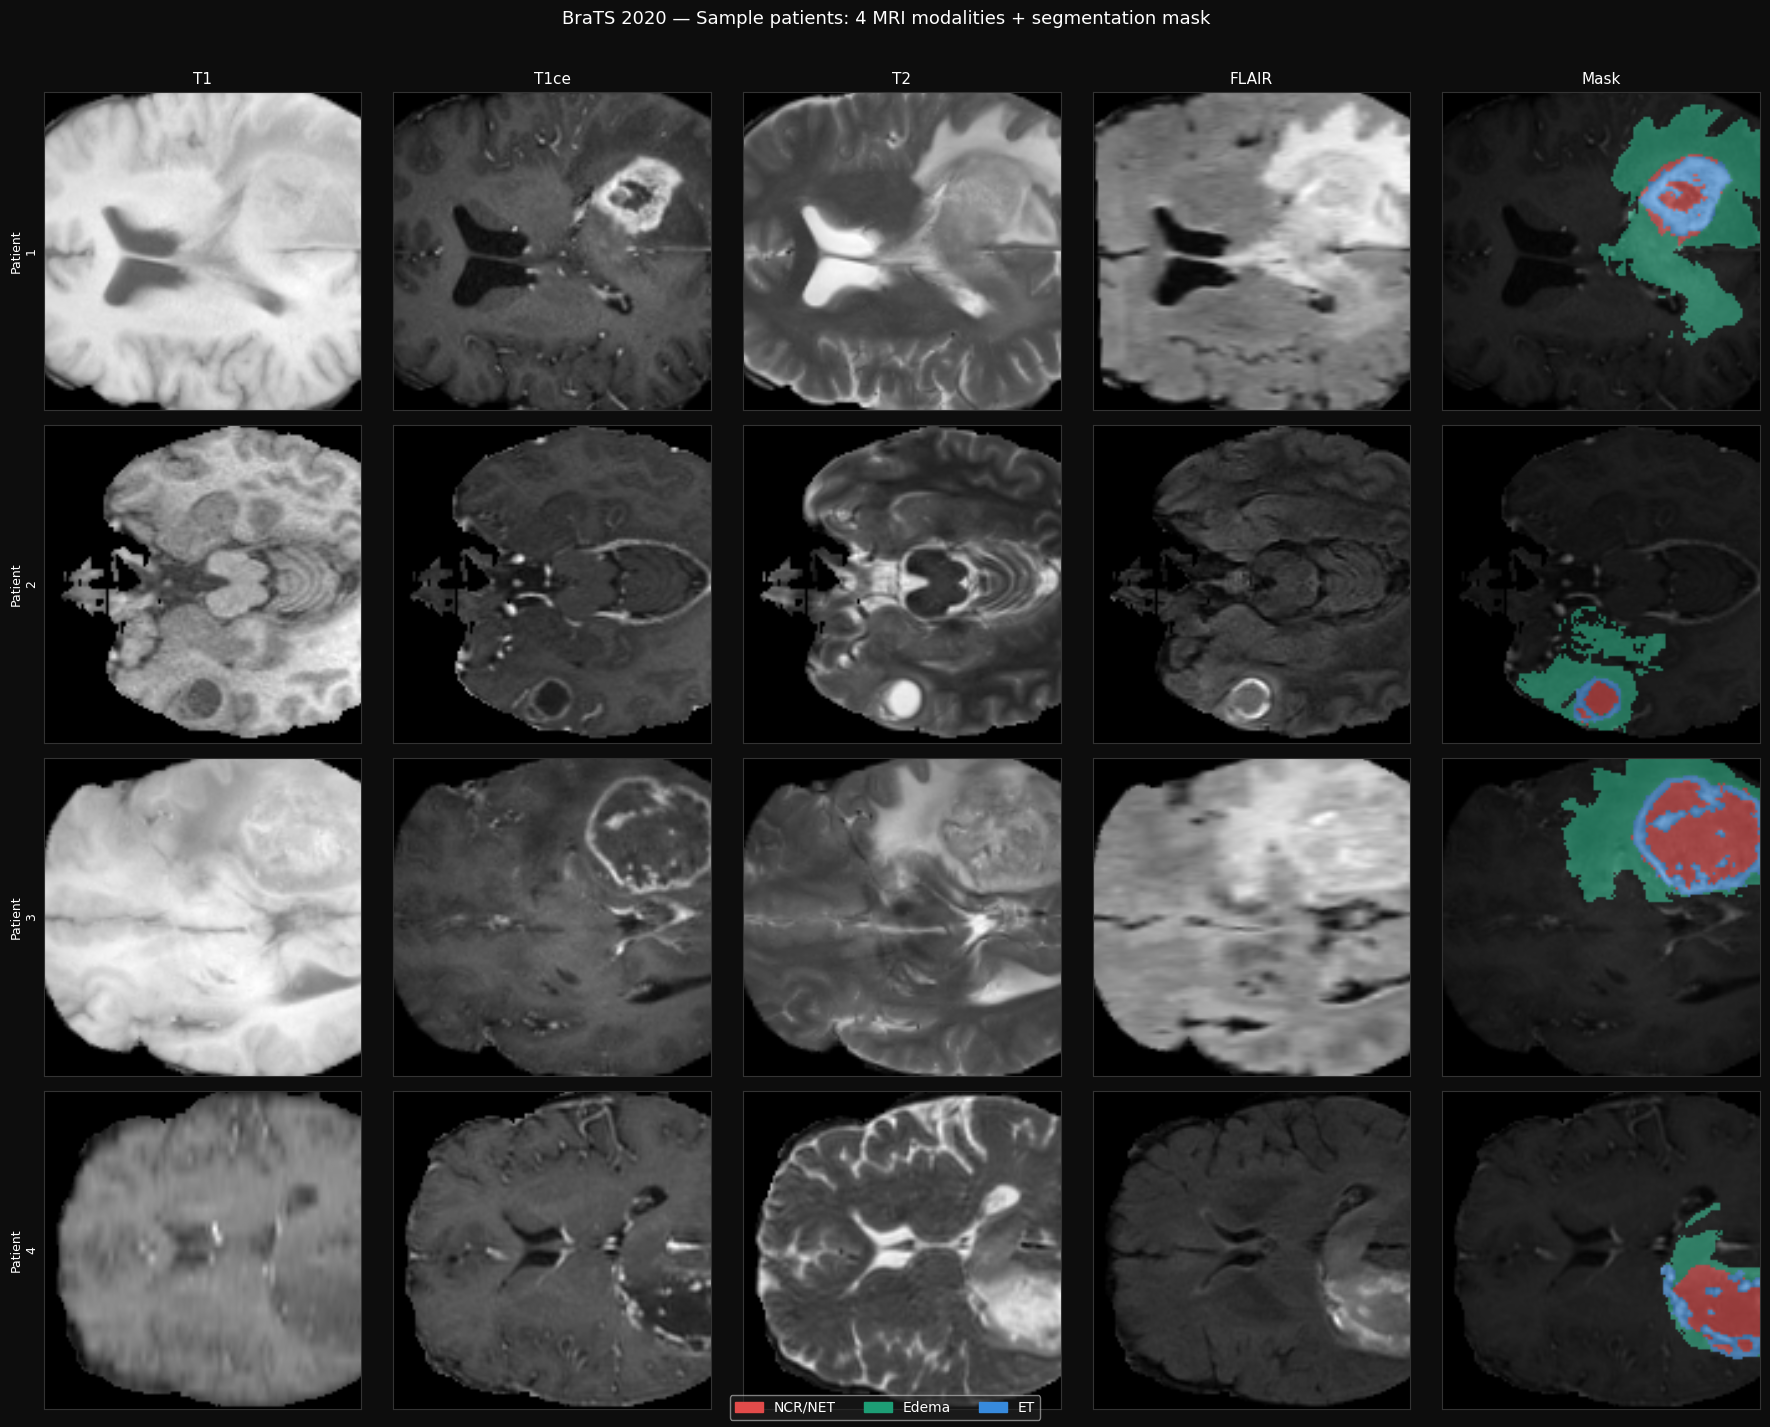

Saved: viz_dataset_modalities.png ✅


In [10]:
# ══════════════════════════════════════════════════════════
#  SECTION A: 4-modality sample grid
# ══════════════════════════════════════════════════════════
N_SAMPLE = 4   # patients to show
MOD_NAMES = ['T1', 'T1ce', 'T2', 'FLAIR', 'Mask']

fig, axes = plt.subplots(N_SAMPLE, 5, figsize=(18, N_SAMPLE*3.5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('BraTS 2020 — Sample patients: 4 MRI modalities + segmentation mask',
             color='white', fontsize=13, y=1.01)

legend_patches = [
    mpatches.Patch(color=COLORS[1], label='NCR/NET'),
    mpatches.Patch(color=COLORS[2], label='Edema'),
    mpatches.Patch(color=COLORS[3], label='ET'),
]

for row, pd_path in enumerate(train_pats[:N_SAMPLE]):
    X, y = load_patient(pd_path, CFG['TARGET_SHAPE'], CFG['CACHE_DIR'])
    # pick the axial slice with most tumour
    best_z = int(np.argmax([(y[:,:,z]>0).sum() for z in range(y.shape[2])]))

    for col, (mod_idx, mod_name) in enumerate(zip(range(5), MOD_NAMES)):
        ax = axes[row, col]
        ax.set_facecolor('black')
        if col < 4:
            ax.imshow(X[:,:,best_z, col], cmap='gray', interpolation='bilinear')
        else:
            ax.imshow(X[:,:,best_z, 1], cmap='gray', interpolation='bilinear')
            ax.imshow(y[:,:,best_z], cmap=CMAP, norm=NORM, alpha=0.6)
        if row == 0:
            ax.set_title(mod_name, color='white', fontsize=11)
        if col == 0:
            ax.set_ylabel(f'Patient\n{row+1}', color='white', fontsize=9)
        ax.set_xticks([]); ax.set_yticks([])
        for sp in ax.spines.values(): sp.set_edgecolor('#333')

fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, labelcolor='white', facecolor='#222', framealpha=0.6)
plt.tight_layout()
plt.savefig('/kaggle/working/viz_dataset_modalities.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved: viz_dataset_modalities.png ✅')

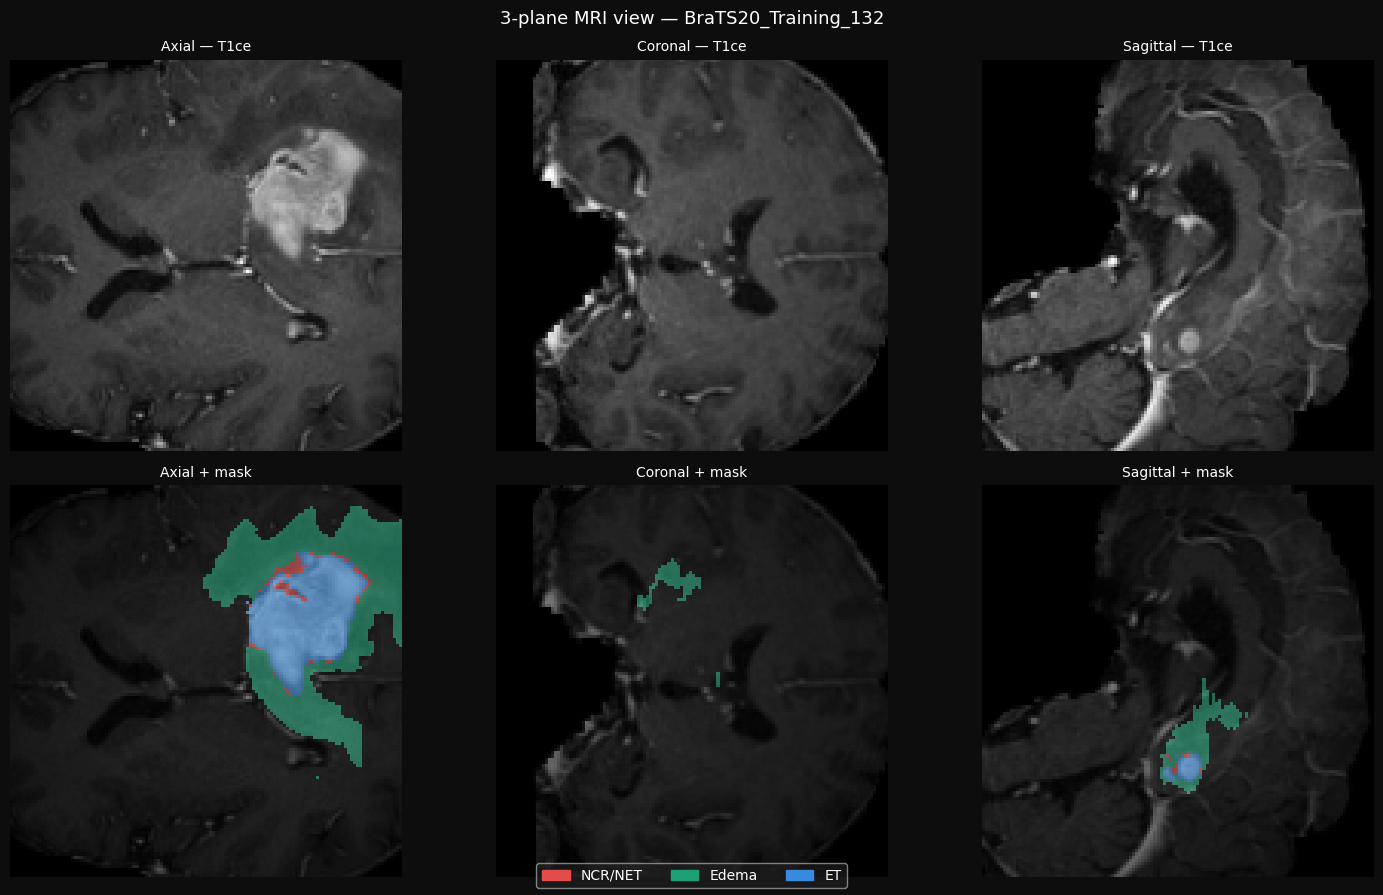

Saved: viz_3plane.png ✅


In [13]:
# ══════════════════════════════════════════════════════════
#  SECTION C: 3-plane view (axial / coronal / sagittal)
# ══════════════════════════════════════════════════════════
pd_path = train_pats[0]
X, y    = load_patient(pd_path, CFG['TARGET_SHAPE'], CFG['CACHE_DIR'])
t1ce    = X[..., 1]
pid     = Path(pd_path).name

mid = [s//2 for s in CFG['TARGET_SHAPE']]
planes = [
    ('Axial',    t1ce[:,:,mid[2]],  y[:,:,mid[2]]),
    ('Coronal',  t1ce[:,mid[1],:],  y[:,mid[1],:]),
    ('Sagittal', t1ce[mid[0],:,:],  y[mid[0],:,:]),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle(f'3-plane MRI view — {pid}', color='white', fontsize=13)

for col, (plane_name, img, mask) in enumerate(planes):
    axes[0, col].imshow(img, cmap='gray')
    axes[0, col].set_title(f'{plane_name} — T1ce', color='white', fontsize=10)
    axes[0, col].axis('off')

    axes[1, col].imshow(img, cmap='gray')
    axes[1, col].imshow(mask, cmap=CMAP, norm=NORM, alpha=0.55)
    axes[1, col].set_title(f'{plane_name} + mask', color='white', fontsize=10)
    axes[1, col].axis('off')

fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, labelcolor='white', facecolor='#222', framealpha=0.6)
plt.tight_layout()
plt.savefig('/kaggle/working/viz_3plane.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved: viz_3plane.png ✅')

## 5 — ✅ Pre-Cache All Patients (Speed Fix)

In [12]:
# Run once — converts all NIfTI → .npy
# After this, each epoch takes ~15s instead of ~130s
print('Pre-caching all patients to .npy ...')
for pd_path in tqdm(all_patients):
    try:
        load_patient(pd_path, CFG['TARGET_SHAPE'], CFG['CACHE_DIR'])
    except Exception as e:
        print(f'  ⚠️ {Path(pd_path).name}: {e}')
print('Cache complete ✅')

Pre-caching all patients to .npy ...


100%|██████████| 368/368 [09:14<00:00,  1.51s/it]

Cache complete ✅


## 6 — ✅ tf.data Pipeline (Zero-Epoch Bug Fixed)

In [14]:
def augment(X, y):
    for axis in range(3):
        if tf.random.uniform(()) > 0.5:
            X = tf.reverse(X, axis=[axis])
            y = tf.reverse(y, axis=[axis])
    return X, y

def make_dataset(patient_list, augment_data=False):
    target  = CFG['TARGET_SHAPE']
    n_cls   = CFG['N_CLASSES']
    cache   = CFG['CACHE_DIR']
    shape_X = (*target, CFG['N_CHANNELS'])
    shape_y = (*target, n_cls)

    # ✅ FIX: use tf.py_function + from_tensor_slices
    #    so dataset length is KNOWN and steps_per_epoch works correctly
    def load_one(pd_bytes):
        def _load(pd_b):
            pd_str = pd_b.numpy().decode()
            X, y   = load_patient(pd_str, target, cache)
            y_oh   = keras.utils.to_categorical(y, n_cls).astype(np.float32)
            return X, y_oh
        X, y = tf.py_function(_load, [pd_bytes], [tf.float32, tf.float32])
        X.set_shape(shape_X)
        y.set_shape(shape_y)
        return X, y

    ds = (
        tf.data.Dataset.from_tensor_slices(patient_list)
        .shuffle(len(patient_list), reshuffle_each_iteration=True)
        .map(load_one, num_parallel_calls=tf.data.AUTOTUNE)  # parallel
        .batch(CFG['BATCH_SIZE'])
        .prefetch(tf.data.AUTOTUNE)
    )
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_pats, augment_data=True)
val_ds   = make_dataset(val_pats,   augment_data=False)
test_ds  = make_dataset(test_pats,  augment_data=False)

# ✅ FIX: compute steps explicitly — eliminates zero-epoch bug
STEPS_PER_EPOCH = math.ceil(len(train_pats) / CFG['BATCH_SIZE'])
VAL_STEPS       = math.ceil(len(val_pats)   / CFG['BATCH_SIZE'])
print(f'steps_per_epoch : {STEPS_PER_EPOCH}')
print(f'validation_steps: {VAL_STEPS}')
print('Datasets ready ✅')

I0000 00:00:1780951945.000164      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


steps_per_epoch : 256
validation_steps: 56
Datasets ready ✅


## 7 — 3D U-Net Model

In [21]:
def conv_block(x, filters, dropout=0.2):
    x = layers.Conv3D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv3D(filters, 3, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_unet3d(input_shape, n_classes, base_filters, depth, dropout):
    inp  = layers.Input(shape=input_shape)
    x    = inp
    skips = []
    for i in range(depth):
        x = conv_block(x, base_filters*(2**i), dropout)
        skips.append(x)
        x = layers.MaxPooling3D(2)(x)
    x = conv_block(x, base_filters*(2**depth), dropout)
    for i in reversed(range(depth)):
        x = layers.Conv3DTranspose(base_filters*(2**i), 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skips[i]])
        x = conv_block(x, base_filters*(2**i), dropout)
    # ✅ FIX: explicit float32 output for mixed precision stability
    x   = layers.Conv3D(n_classes, 1, dtype='float32')(x)
    out = layers.Activation('softmax', dtype='float32')(x)
    return Model(inp, out, name='UNet3D_v2')

model = build_unet3d(
    input_shape  = (*CFG['TARGET_SHAPE'], CFG['N_CHANNELS']),
    n_classes    = CFG['N_CLASSES'],
    base_filters = CFG['BASE_FILTERS'],
    depth        = CFG['DEPTH'],
    dropout      = CFG['DROPOUT'],
)
model.summary(line_length=80)
print(f'\nTotal parameters: {model.count_params():,}')

Model: "UNet3D_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)          ┃ Output Shape      ┃     Param # ┃ Connected to       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1         │ (None, 128, 128,  │           0 │ -                  │
│ (InputLayer)          │ 128, 4)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv3d_19 (Conv3D)    │ (None, 128, 128,  │       1,728 │ input_layer_1[0][… │
│                       │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, 128, 128,  │          64 │ conv3d_19[0][0]    │
│ (BatchNormalization)  │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_18 (ReLU)       │ (None, 128, 128,  │           0 │ batch_normalizati… │
│                       │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_9 (Dropout)   │ (None, 128, 128,  │           0 │ re_lu_18[0][0]     │
│                       │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv3d_20 (Conv3D)    │ (None, 128, 128,  │       6,912 │ dropout_9[0][0]    │
│                       │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, 128, 128,  │          64 │ conv3d_20[0][0]    │
│ (BatchNormalization)  │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_19 (ReLU)       │ (None, 128, 128,  │           0 │ batch_normalizati… │
│                       │ 128, 16)          │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ max_pooling3d_4       │ (None, 64, 64,    │           0 │ re_lu_19[0][0]     │
│ (MaxPooling3D)        │ 64, 16)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv3d_21 (Conv3D)    │ (None, 64, 64,    │      13,824 │ max_pooling3d_4[0… │
│                       │ 64, 32)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, 64, 64,    │         128 │ conv3d_21[0][0]    │
│ (BatchNormalization)  │ 64, 32)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_20 (ReLU)       │ (None, 64, 64,    │           0 │ batch_normalizati… │
│                       │ 64, 32)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ dropout_10 (Dropout)  │ (None, 64, 64,    │           0 │ re_lu_20[0][0]     │
│                       │ 64, 32)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ conv3d_22 (Conv3D)    │ (None, 64, 64,    │      27,648 │ dropout_10[0][0]   │
│                       │ 64, 32)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ batch_normalization_… │ (None, 64, 64,    │         128 │ conv3d_22[0][0]    │
│ (BatchNormalization)  │ 64, 32)           │             │                    │
├───────────────────────┼───────────────────┼─────────────┼────────────────────┤
│ re_lu_21 (ReLU)       │ (None, 64, 64,    │           0 │ batch_normalizati… │
│                       │ 64, 3

 Total params: 5,650,676 (21.56 MB)

 Trainable params: 5,647,732 (21.54 MB)

 Non-trainable params: 2,944 (11.50 KB)


Total parameters: 5,650,676


## 8 — Loss & Metrics

In [22]:
def mean_dice_coef(y_true, y_pred):
    dices = []
    for i in range(1, CFG['N_CLASSES']):
        yt = y_true[..., i]; yp = y_pred[..., i]
        dices.append(
            (2*tf.reduce_sum(yt*yp) + SMOOTH) /
            (tf.reduce_sum(yt) + tf.reduce_sum(yp) + SMOOTH)
        )
    return tf.reduce_mean(dices)

def mean_iou(y_true, y_pred):
    yp = tf.cast(tf.argmax(y_pred, -1), tf.float32)
    yt = tf.cast(tf.argmax(y_true, -1), tf.float32)
    ious = []
    for c in range(1, CFG['N_CLASSES']):
        tp = tf.reduce_sum(tf.cast((yt==c)&(yp==c), tf.float32))
        fp = tf.reduce_sum(tf.cast((yt!=c)&(yp==c), tf.float32))
        fn = tf.reduce_sum(tf.cast((yt==c)&(yp!=c), tf.float32))
        ious.append((tp+SMOOTH)/(tp+fp+fn+SMOOTH))
    return tf.reduce_mean(ious)

def combined_loss(y_true, y_pred):
    dl = 1.0 - mean_dice_coef(y_true, y_pred)
    ce = tf.keras.losses.categorical_crossentropy(y_true, y_pred)
    return dl + tf.reduce_mean(tf.clip_by_value(ce, 0, 10))

CUSTOM = {
    'combined_loss':  combined_loss,
    'mean_dice_coef': mean_dice_coef,
    'mean_iou':       mean_iou,
}

model.compile(
    optimizer=keras.optimizers.Adam(CFG['LR']),
    loss=combined_loss,
    metrics=[mean_dice_coef, mean_iou],
)
print('Model compiled ✅')

Model compiled ✅


## 9 — Training

In [23]:
cb_list = [
    callbacks.ModelCheckpoint(
        CFG['MODEL_PATH'], monitor='val_mean_dice_coef',
        mode='max', save_best_only=True, verbose=1),
    callbacks.EarlyStopping(
        monitor='val_mean_dice_coef', mode='max',
        patience=CFG['PATIENCE'], restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=7, min_lr=1e-7, verbose=1),
    callbacks.CSVLogger(CFG['LOG_PATH']),
]

print(f'Training for up to {CFG["EPOCHS"]} epochs...')
print(f'steps_per_epoch={STEPS_PER_EPOCH}  validation_steps={VAL_STEPS}')
t0 = time.time()

history = model.fit(
    train_ds,
    validation_data    = val_ds,
    epochs             = CFG['EPOCHS'],
    steps_per_epoch    = STEPS_PER_EPOCH,   # ✅ zero-epoch bug fixed
    validation_steps   = VAL_STEPS,         # ✅ zero-epoch bug fixed
    callbacks          = cb_list,
    verbose            = 1,
)

print(f'\n✅ Training complete in {(time.time()-t0)/60:.1f} min')
print(f'Best val Dice: {max(history.history["val_mean_dice_coef"])*100:.2f}%')

Training for up to 100 epochs...
steps_per_epoch=256  validation_steps=56
Epoch 1/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 673ms/step - loss: 2.2012 - mean_dice_coef: 0.0488 - mean_iou: 0.0619
Epoch 1: val_mean_dice_coef improved from None to 0.05066, saving model to /kaggle/working/brainseg_v2_best.keras

Epoch 1: finished saving model to /kaggle/working/brainseg_v2_best.keras
256/256 ━━━━━━━━━━━━━━━━━━━━ 235s 803ms/step - loss: 1.9221 - mean_dice_coef: 0.0552 - mean_iou: 0.1002 - val_loss: 2.9872 - val_mean_dice_coef: 0.0507 - val_mean_iou: 0.0481 - learning_rate: 1.0000e-04
Epoch 2/100
256/256 ━━━━━━━━━━━━━━━━━━━━ 0s 623ms/step - loss: 1.6301 - mean_dice_coef: 0.0699 - mean_iou: 0.1984
Epoch 2: val_mean_dice_coef improved from 0.05066 to 0.08015, saving model to /kaggle/working/brainseg_v2_best.keras

Epoch 2: finished saving model to /kaggle/working/brainseg_v2_best.keras
256/256 ━━━━━━━━━━━━━━━━━━━━ 175s 678ms/step - loss: 1.5831 - mean_dice_coef: 0.0792 - mean_iou: 0.2250 - val_loss: 

## 10 — Training Curves + Overfitting Analysis

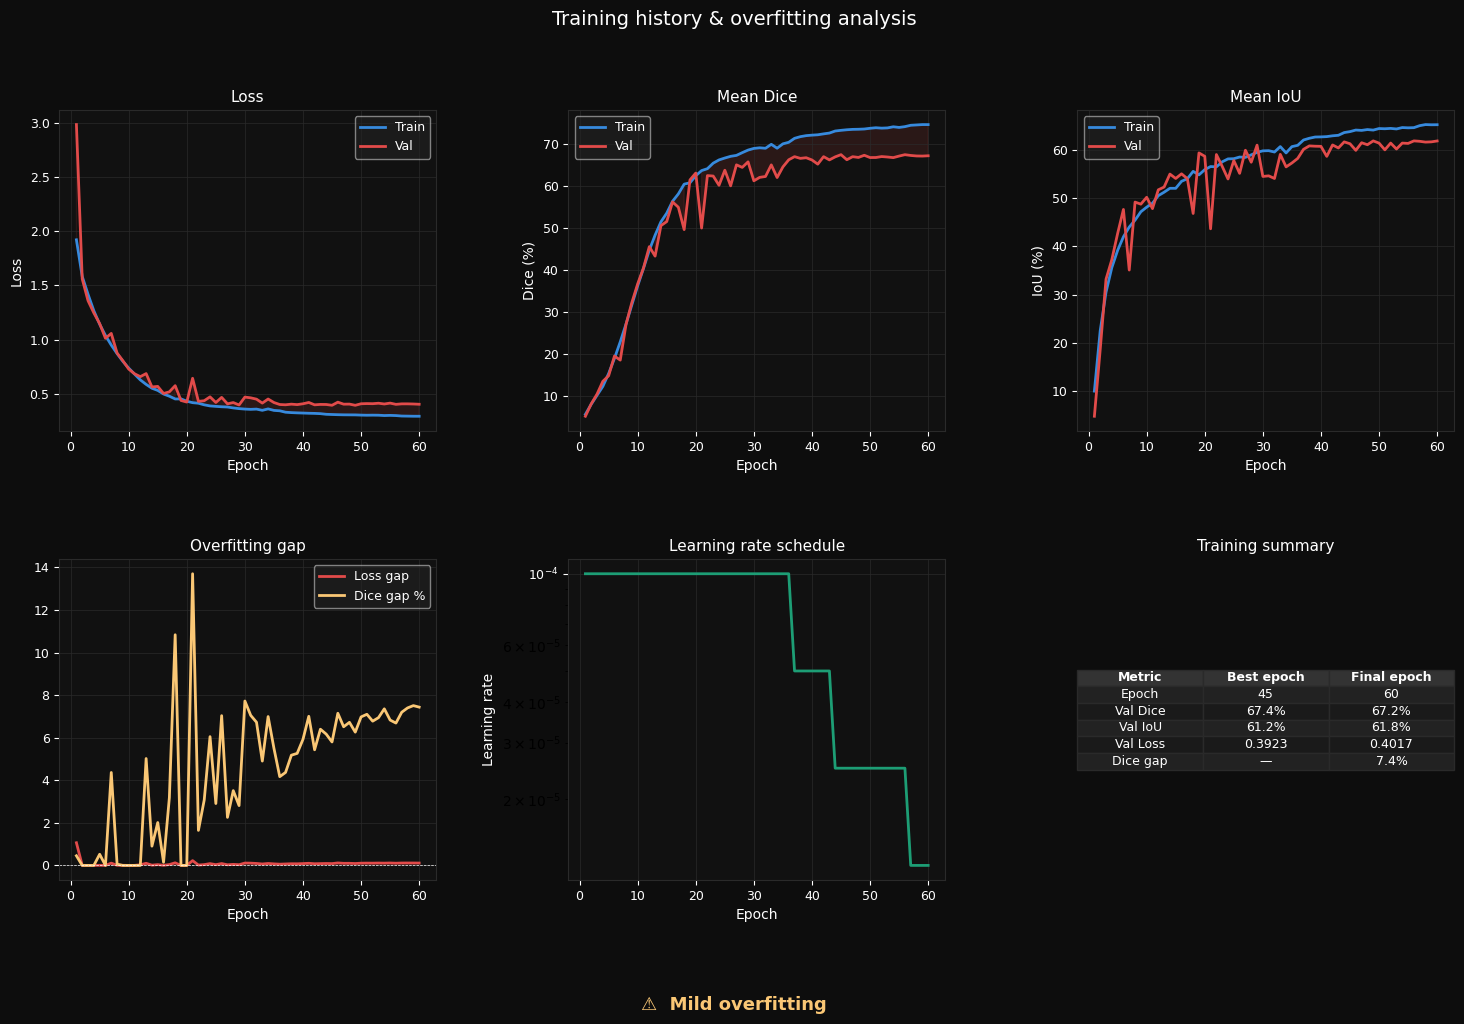

⚠️  Mild overfitting  (Dice gap: 7.4%)


In [24]:
import pandas as pd

df  = pd.read_csv(CFG['LOG_PATH'])
# Drop any remaining zero-epochs (safety net)
df  = df[df['mean_dice_coef'] > 0.001].reset_index(drop=True)
eps = np.arange(1, len(df)+1)

fig = plt.figure(figsize=(18, 10), facecolor=BG_DARK)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

def sax(ax, title):
    ax.set_facecolor(AX_DARK)
    ax.set_title(title, color='white', fontsize=11, pad=6)
    ax.tick_params(colors='white', labelsize=9)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)
    ax.grid(True, color=GRID_COL, linewidth=0.5)

# Loss
ax = fig.add_subplot(gs[0,0])
ax.plot(eps, df['loss'],     color='#378ADD', lw=2, label='Train')
ax.plot(eps, df['val_loss'], color='#E24B4A', lw=2, label='Val')
ax.fill_between(eps, df['loss'], df['val_loss'],
    where=df['val_loss']>df['loss'], alpha=0.12, color='#E24B4A')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(fontsize=9, labelcolor='white', facecolor='#222', framealpha=0.6)
sax(ax, 'Loss')

# Dice
ax = fig.add_subplot(gs[0,1])
ax.plot(eps, df['mean_dice_coef']*100,     color='#378ADD', lw=2, label='Train')
ax.plot(eps, df['val_mean_dice_coef']*100, color='#E24B4A', lw=2, label='Val')
ax.fill_between(eps, df['mean_dice_coef']*100, df['val_mean_dice_coef']*100,
    where=df['mean_dice_coef']>df['val_mean_dice_coef'],
    alpha=0.12, color='#E24B4A')
ax.set_xlabel('Epoch'); ax.set_ylabel('Dice (%)')
ax.legend(fontsize=9, labelcolor='white', facecolor='#222', framealpha=0.6)
sax(ax, 'Mean Dice')

# IoU
ax = fig.add_subplot(gs[0,2])
ax.plot(eps, df['mean_iou']*100,     color='#378ADD', lw=2, label='Train')
ax.plot(eps, df['val_mean_iou']*100, color='#E24B4A', lw=2, label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('IoU (%)')
ax.legend(fontsize=9, labelcolor='white', facecolor='#222', framealpha=0.6)
sax(ax, 'Mean IoU')

# Loss gap
gap_loss = (df['val_loss'] - df['loss']).clip(lower=0)
gap_dice = (df['mean_dice_coef'] - df['val_mean_dice_coef']).clip(lower=0)*100
ax = fig.add_subplot(gs[1,0])
ax.plot(eps, gap_loss, color='#E24B4A', lw=2, label='Loss gap')
ax.plot(eps, gap_dice, color='#FAC775', lw=2, label='Dice gap %')
ax.axhline(0, color='white', lw=0.5, linestyle='--')
ax.set_xlabel('Epoch')
ax.legend(fontsize=9, labelcolor='white', facecolor='#222', framealpha=0.6)
sax(ax, 'Overfitting gap')

# LR curve
if 'learning_rate' in df.columns:
    ax = fig.add_subplot(gs[1,1])
    ax.semilogy(eps, df['learning_rate'], color='#1D9E75', lw=2)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Learning rate')
    sax(ax, 'Learning rate schedule')

# Best epoch stats
best_ep = df['val_mean_dice_coef'].idxmax()
final_gap = gap_dice.iloc[-1] if len(gap_dice) else 0
verdict = ('✅ No significant overfitting' if final_gap < 5
           else '⚠️  Mild overfitting' if final_gap < 12
           else '❌ Overfitting detected')
vcol = '#1D9E75' if final_gap < 5 else '#FAC775' if final_gap < 12 else '#E24B4A'

ax = fig.add_subplot(gs[1,2])
ax.axis('off')
stats = [
    ['Metric', 'Best epoch', 'Final epoch'],
    ['Epoch', str(best_ep+1), str(len(df))],
    ['Val Dice', f'{df["val_mean_dice_coef"].iloc[best_ep]*100:.1f}%',
                 f'{df["val_mean_dice_coef"].iloc[-1]*100:.1f}%'],
    ['Val IoU',  f'{df["val_mean_iou"].iloc[best_ep]*100:.1f}%',
                 f'{df["val_mean_iou"].iloc[-1]*100:.1f}%'],
    ['Val Loss', f'{df["val_loss"].iloc[best_ep]:.4f}',
                 f'{df["val_loss"].iloc[-1]:.4f}'],
    ['Dice gap', '—', f'{final_gap:.1f}%'],
]
tbl = ax.table(cellText=stats[1:], colLabels=stats[0],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c), cell in tbl.get_celld().items():
    cell.set_facecolor('#1a1a1a' if r%2==0 else '#222')
    cell.set_text_props(color='white')
    cell.set_edgecolor(GRID_COL)
    if r == 0: cell.set_facecolor('#333'); cell.set_text_props(color='white', fontweight='bold')
ax.set_title('Training summary', color='white', fontsize=11, pad=6)

fig.text(0.5, -0.02, verdict, ha='center', color=vcol,
         fontsize=13, fontweight='bold')
plt.suptitle('Training history & overfitting analysis', color='white', fontsize=14)
plt.savefig('/kaggle/working/viz_training_curves.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print(f'{verdict}  (Dice gap: {final_gap:.1f}%)')

## 11 — Load Best Model

In [25]:
def find_model():
    candidates = (
        glob.glob('/kaggle/working/*.keras') +
        glob.glob('/kaggle/input/**/*.keras', recursive=True) +
        glob.glob('/kaggle/working/*.h5') +
        glob.glob('/kaggle/input/**/*.h5', recursive=True)
    )
    if not candidates:
        raise FileNotFoundError('No model found — run training or add dataset')
    return sorted(candidates, key=os.path.getmtime, reverse=True)[0]

MODEL_PATH = find_model()
model = tf.keras.models.load_model(MODEL_PATH, custom_objects=CUSTOM)
size_mb = os.path.getsize(MODEL_PATH)/1024**2
print(f'Loaded: {MODEL_PATH}  ({size_mb:.1f} MB)')
print(f'Parameters: {model.count_params():,}')

def predict_patient(pd_path):
    X, y = load_patient(pd_path, CFG['TARGET_SHAPE'], CFG['CACHE_DIR'])
    pred = model.predict(X[np.newaxis], verbose=0)
    mask = np.argmax(pred[0], axis=-1).astype(np.uint8)
    return X, y, mask

print('predict_patient() ready ✅')

Loaded: /kaggle/working/brainseg_v2_best.keras  (108.1 MB)
Parameters: 5,650,676
predict_patient() ready ✅


## 12 — 🔬 Prediction Visualization

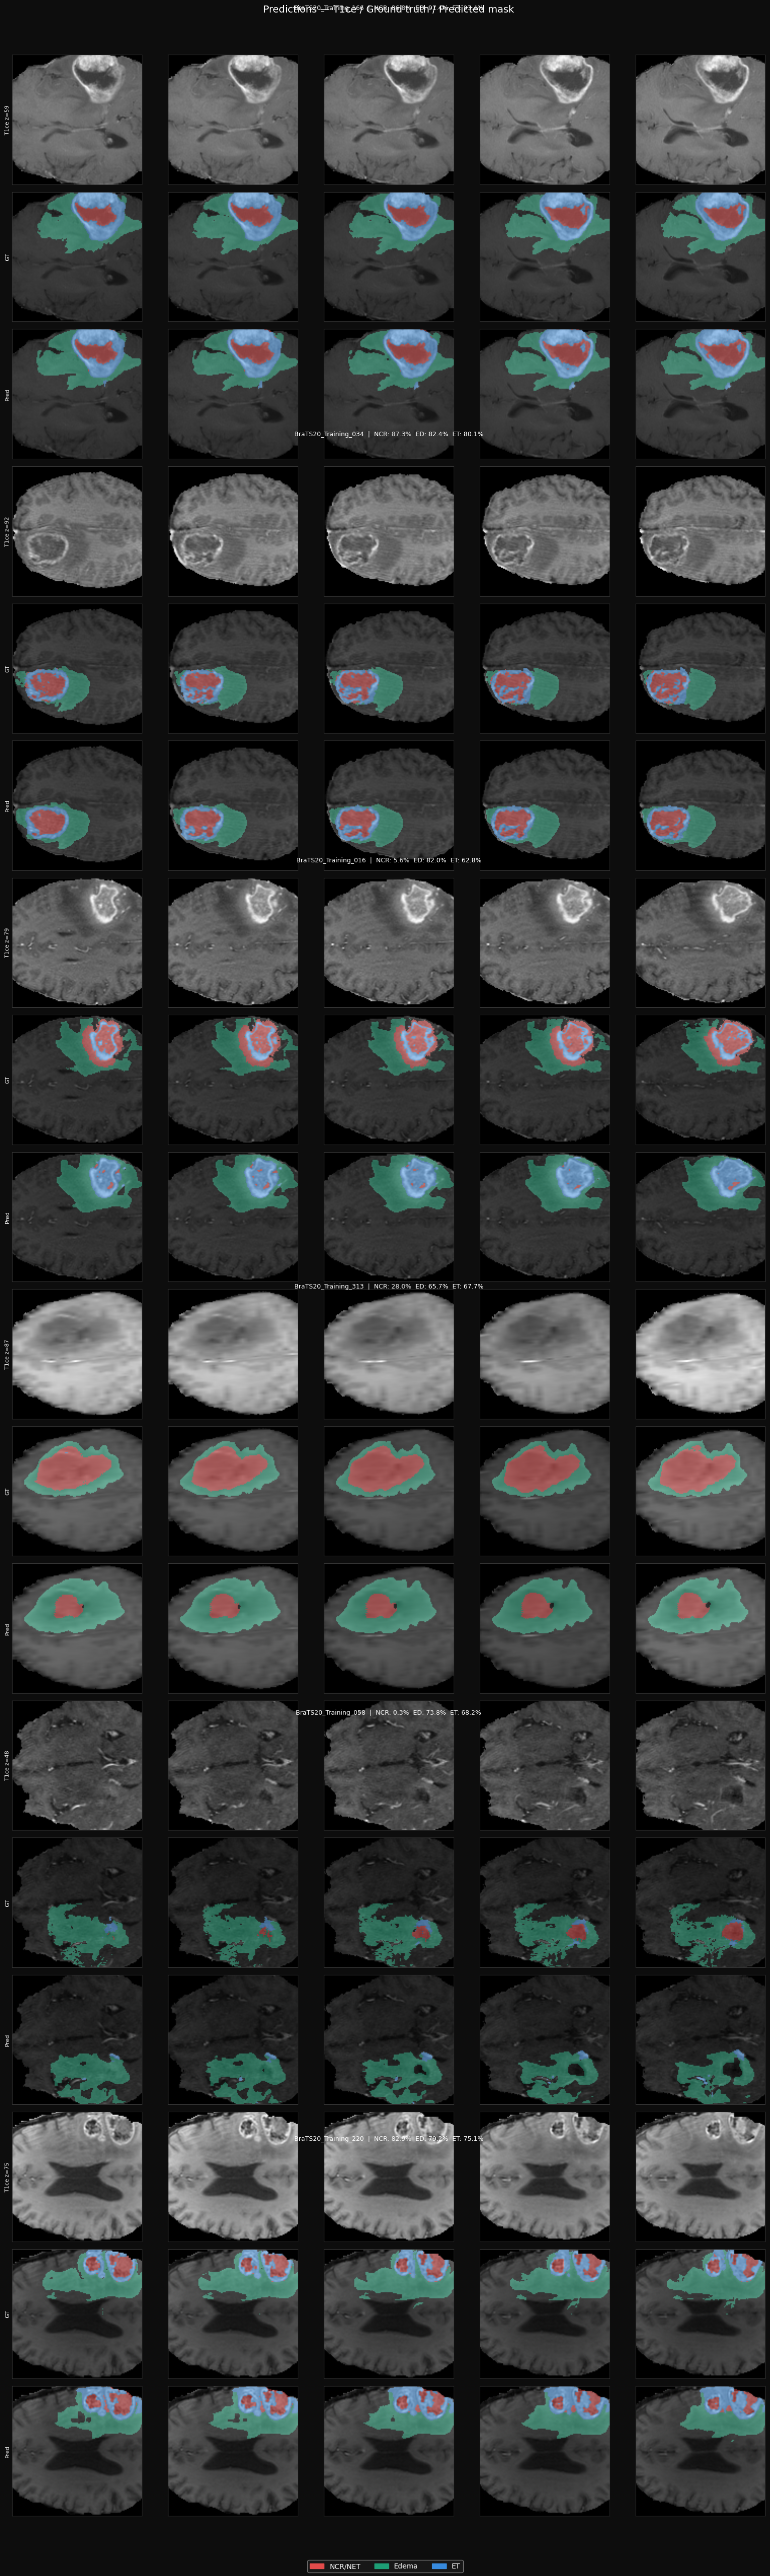

Saved: viz_predictions.png ✅


In [26]:
# ══════════════════════════════════════════════════════════
#  Grid: T1ce | Ground truth | Prediction
#  Shows N_PATIENTS × N_SLICES with per-patient Dice
# ══════════════════════════════════════════════════════════
N_PATIENTS = 6
N_SLICES   = 5

fig = plt.figure(figsize=(N_SLICES*3.2, N_PATIENTS*8.5))
fig.patch.set_facecolor(BG_DARK)
fig.suptitle('Predictions — T1ce / Ground truth / Predicted mask',
             color='white', fontsize=14, y=1.005)

for p_idx, pd_path in enumerate(test_pats[:N_PATIENTS]):
    try:
        X, y_true, pred = predict_patient(pd_path)
        pid  = Path(pd_path).name
        t1ce = X[..., 1]
        D    = t1ce.shape[2]

        # pick slices with most tumour voxels
        chosen = sorted(
            sorted(range(D), key=lambda z:(y_true[:,:,z]>0).sum(), reverse=True)[:N_SLICES]
        )

        # per-patient Dice per tumor class
        pat_dice = []
        for c in range(1,4):
            gt=(y_true==c); pr=(pred==c)
            tp=(gt&pr).sum(); fp=(~gt&pr).sum(); fn=(gt&~pr).sum()
            pat_dice.append((2*tp+SMOOTH)/(2*tp+fp+fn+SMOOTH)*100)

        base = p_idx * 3
        for col, z in enumerate(chosen):
            bg = t1ce[:,:,z]
            for row_off, (overlay, lbl) in enumerate([
                (None,         f'T1ce z={z}'),
                (y_true[:,:,z],'GT'),
                (pred[:,:,z],  'Pred'),
            ]):
                ax = fig.add_subplot(N_PATIENTS*3, N_SLICES,
                                     (base+row_off)*N_SLICES + col+1)
                ax.imshow(bg, cmap='gray', interpolation='bilinear')
                if overlay is not None:
                    ax.imshow(overlay, cmap=CMAP, norm=NORM, alpha=0.5)
                if col == 0:
                    ax.set_ylabel(lbl, color='white', fontsize=8, labelpad=3)
                ax.set_xticks([]); ax.set_yticks([])
                for sp in ax.spines.values(): sp.set_edgecolor('#333')

        fig.text(
            0.5, 1 - (p_idx/N_PATIENTS) + 0.003,
            f'{pid}  |  NCR: {pat_dice[0]:.1f}%  '
            f'ED: {pat_dice[1]:.1f}%  ET: {pat_dice[2]:.1f}%',
            ha='center', color='white', fontsize=9,
            transform=fig.transFigure
        )
    except Exception as e:
        print(f'  ⚠️ {Path(pd_path).name}: {e}')

fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=10, labelcolor='white', facecolor='#222', framealpha=0.5)
plt.tight_layout(rect=[0, 0.02, 1, 0.995])
plt.savefig('/kaggle/working/viz_predictions.png', dpi=120,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved: viz_predictions.png ✅')

## 13 — 📐 Accuracy Matrix — All Classes & Full Model

In [27]:
# ══════════════════════════════════════════════════════════
#  Compute per-class and overall metrics on full test set
# ══════════════════════════════════════════════════════════
print(f'Evaluating {len(test_pats)} test patients...')

tp_all = np.zeros(4); fp_all = np.zeros(4); fn_all = np.zeros(4)
correct_vox = 0; total_vox = 0
per_patient  = {c: [] for c in CLASS_NAMES}

for pd_path in tqdm(test_pats):
    try:
        X, y_true, pred = predict_patient(pd_path)
        correct_vox += (pred == y_true).sum()
        total_vox   += y_true.size
        for c, name in enumerate(CLASS_NAMES):
            gt=(y_true==c); pr=(pred==c)
            tp=(gt&pr).sum(); fp=(~gt&pr).sum(); fn=(gt&~pr).sum()
            tp_all[c]+=tp; fp_all[c]+=fp; fn_all[c]+=fn
            per_patient[name].append(
                float((2*tp+SMOOTH)/(2*tp+fp+fn+SMOOTH))*100)
    except Exception as e:
        print(f'  ⚠️ {Path(pd_path).name}: {e}')

overall_acc = correct_vox / max(total_vox, 1)
dice  = (2*tp_all+SMOOTH)/(2*tp_all+fp_all+fn_all+SMOOTH)*100
iou   = (tp_all+SMOOTH)/(tp_all+fp_all+fn_all+SMOOTH)*100
prec  = (tp_all+SMOOTH)/(tp_all+fp_all+SMOOTH)*100
rec   = (tp_all+SMOOTH)/(tp_all+fn_all+SMOOTH)*100
f1    = 2*(prec*rec)/(prec+rec+SMOOTH)

# Console table
print(f'\n{"="*65}')
print(f'  Overall voxel accuracy : {overall_acc*100:.2f}%')
print(f'  Mean Dice (tumor only) : {dice[1:].mean():.1f}%')
print(f'  Mean IoU  (tumor only) : {iou[1:].mean():.1f}%')
print(f'{"="*65}')
print(f'  {"Class":<14}{"Dice":>8}{"IoU":>8}{"Prec":>8}{"Recall":>8}{"F1":>8}')
print(f'  {"-"*58}')
for c, name in enumerate(CLASS_NAMES):
    print(f'  {name:<14}{dice[c]:>7.1f}%{iou[c]:>7.1f}%'
          f'{prec[c]:>7.1f}%{rec[c]:>7.1f}%{f1[c]:>7.1f}%')
print(f'{"="*65}')

Evaluating 56 test patients...


100%|██████████| 56/56 [00:43<00:00,  1.30it/s]


  Overall voxel accuracy : 97.97%
  Mean Dice (tumor only) : 67.7%
  Mean IoU  (tumor only) : 52.4%
  Class             Dice     IoU    Prec  Recall      F1
  ----------------------------------------------------------
  Background       99.4%   98.7%   99.5%   99.2%   99.4%
  NCR/NET          50.4%   33.7%   71.3%   39.0%   50.4%
  Edema            74.6%   59.5%   68.2%   82.3%   74.6%
  ET               78.0%   64.0%   70.5%   87.4%   78.0%


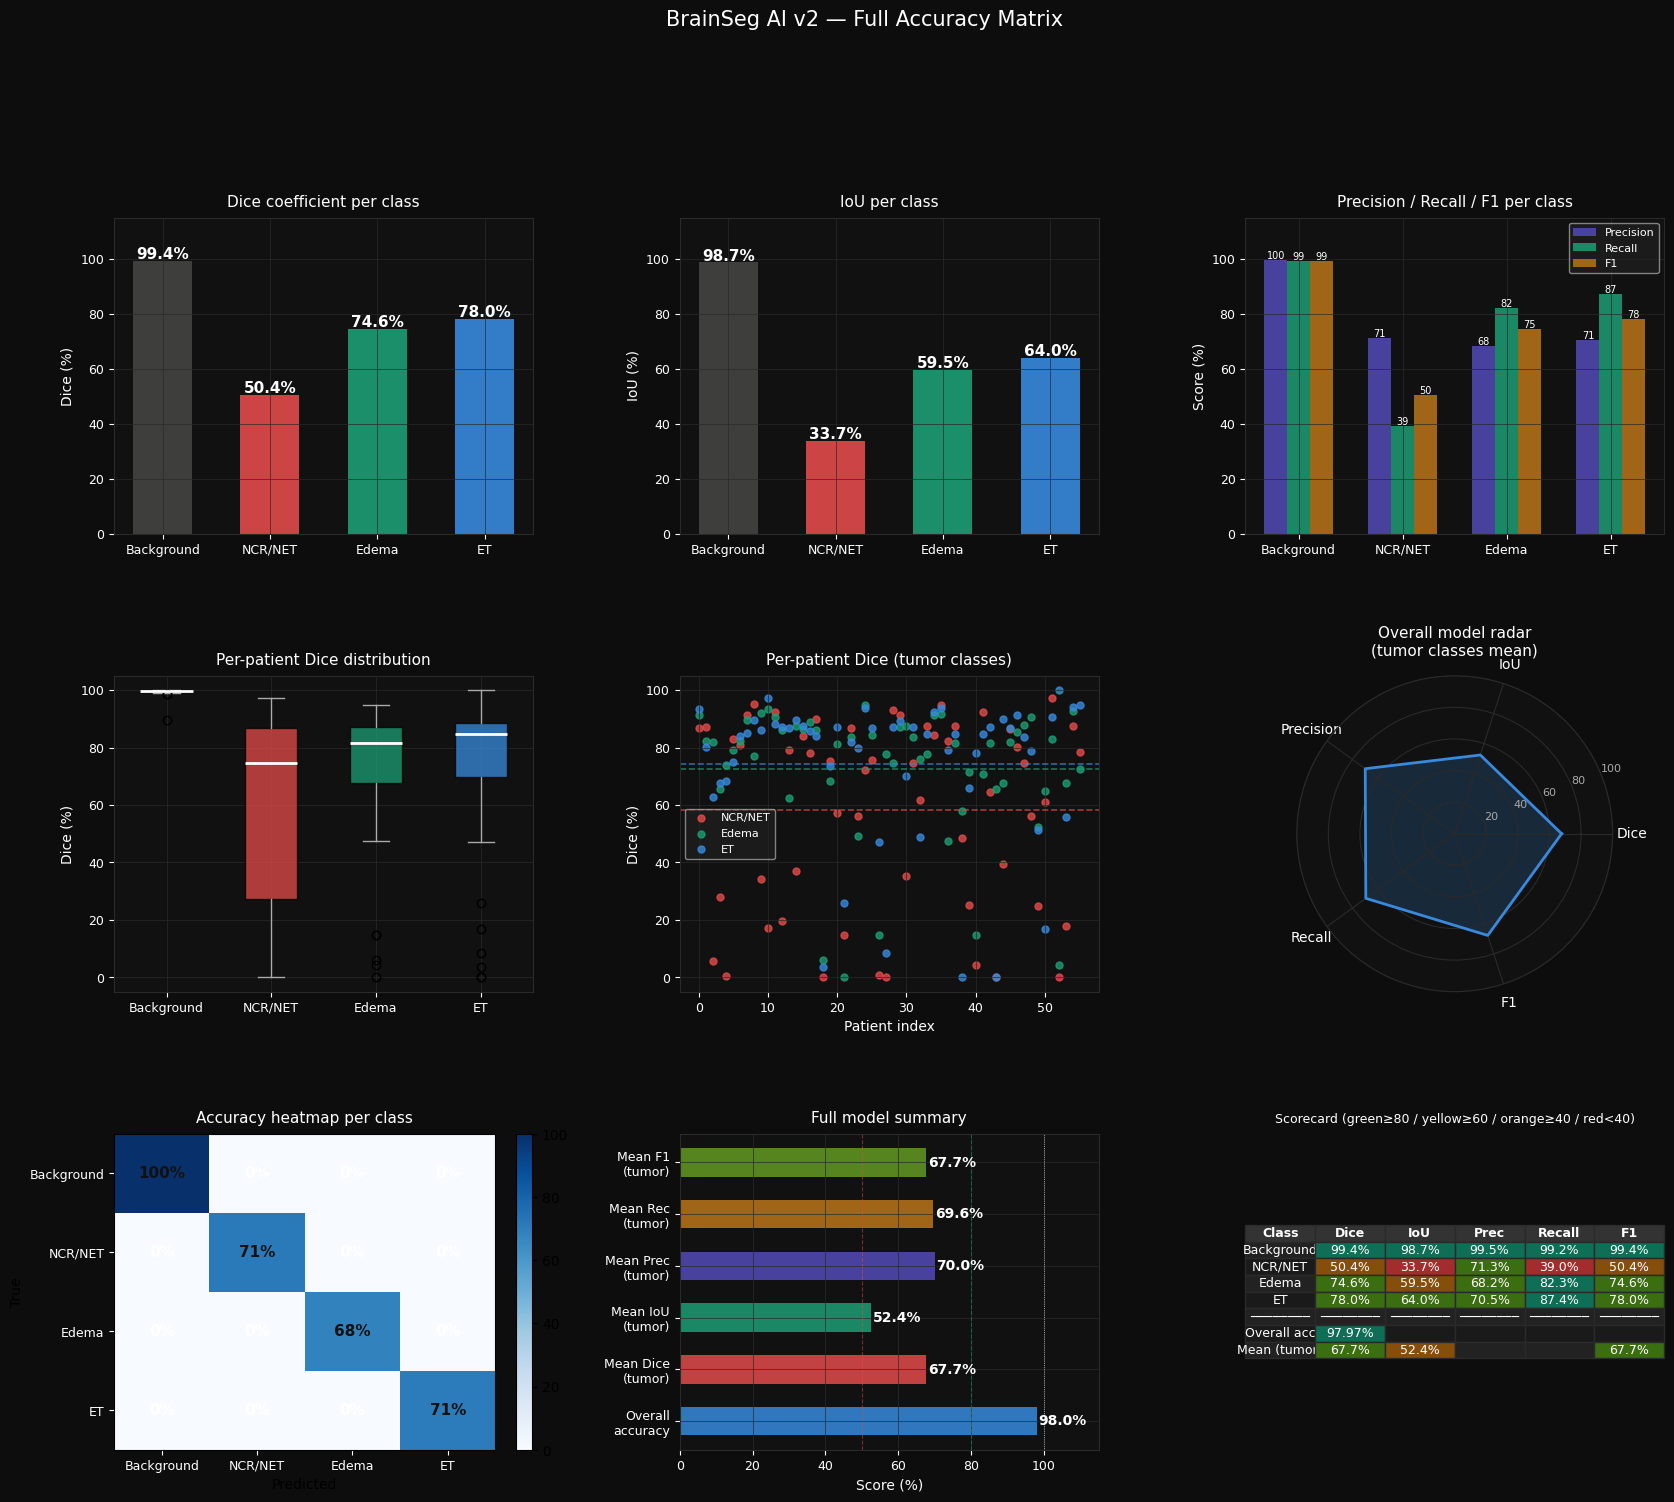

Saved: viz_accuracy_matrix.png ✅


In [28]:
# ══════════════════════════════════════════════════════════
#  ACCURACY MATRIX — full 9-panel figure
# ══════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 16), facecolor=BG_DARK)
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

def sax(ax, title):
    ax.set_facecolor(AX_DARK)
    ax.set_title(title, color='white', fontsize=11, pad=8)
    ax.tick_params(colors='white', labelsize=9)
    ax.xaxis.label.set_color('white')
    ax.yaxis.label.set_color('white')
    for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)
    ax.grid(True, color=GRID_COL, linewidth=0.5)

bar_w = 0.55

# ── Row 0 ─────────────────────────────────────────────────

# [0,0] Dice per class
ax = fig.add_subplot(gs[0,0])
bars = ax.bar(CLASS_NAMES, dice, color=COLORS, width=bar_w, alpha=0.9)
for b,v in zip(bars,dice):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%',
            ha='center', color='white', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115); ax.set_ylabel('Dice (%)')
sax(ax, 'Dice coefficient per class')

# [0,1] IoU per class
ax = fig.add_subplot(gs[0,1])
bars = ax.bar(CLASS_NAMES, iou, color=COLORS, width=bar_w, alpha=0.9)
for b,v in zip(bars,iou):
    ax.text(b.get_x()+b.get_width()/2, v+0.8, f'{v:.1f}%',
            ha='center', color='white', fontsize=11, fontweight='bold')
ax.set_ylim(0, 115); ax.set_ylabel('IoU (%)')
sax(ax, 'IoU per class')

# [0,2] Prec / Recall / F1 grouped
ax  = fig.add_subplot(gs[0,2])
x   = np.arange(4); w = 0.22
b1  = ax.bar(x-w,  prec, w, label='Precision', color='#534AB7', alpha=0.85)
b2  = ax.bar(x,    rec,  w, label='Recall',    color='#1D9E75', alpha=0.85)
b3  = ax.bar(x+w,  f1,   w, label='F1',        color='#BA7517', alpha=0.85)
for bs in [b1,b2,b3]:
    for b in bs:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.5,
                f'{b.get_height():.0f}', ha='center', color='white', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=9)
ax.set_ylim(0, 115); ax.set_ylabel('Score (%)')
ax.legend(fontsize=8, labelcolor='white', facecolor='#222', framealpha=0.6)
sax(ax, 'Precision / Recall / F1 per class')

# ── Row 1 ─────────────────────────────────────────────────

# [1,0] Box plot — per-patient Dice distribution
ax  = fig.add_subplot(gs[1,0])
data = [per_patient[c] for c in CLASS_NAMES]
bp   = ax.boxplot(data, patch_artist=True, widths=0.5,
                  medianprops=dict(color='white', linewidth=2))
for patch,col in zip(bp['boxes'],COLORS):
    patch.set_facecolor(col); patch.set_alpha(0.75)
for el in ['whiskers','caps','fliers']:
    for item in bp[el]: item.set_color('#aaa')
ax.set_xticklabels(CLASS_NAMES); ax.set_ylabel('Dice (%)')
sax(ax, 'Per-patient Dice distribution')

# [1,1] Scatter — per-patient Dice (tumor classes)
ax  = fig.add_subplot(gs[1,1])
for name,col in zip(CLASS_NAMES[1:],COLORS[1:]):
    vals = per_patient[name]
    ax.scatter(range(len(vals)), vals, color=col, s=25, alpha=0.8, label=name)
    ax.axhline(np.mean(vals), color=col, lw=1.2, linestyle='--', alpha=0.7)
ax.set_xlabel('Patient index'); ax.set_ylabel('Dice (%)')
ax.legend(fontsize=8, labelcolor='white', facecolor='#222', framealpha=0.6)
sax(ax, 'Per-patient Dice (tumor classes)')

# [1,2] Radar / spider chart
ax   = fig.add_subplot(gs[1,2], polar=True)
ax.set_facecolor(AX_DARK)
metrics_radar = np.array([dice[1:].mean(), iou[1:].mean(),
                           prec[1:].mean(), rec[1:].mean(), f1[1:].mean()])
labels_r = ['Dice', 'IoU', 'Precision', 'Recall', 'F1']
N_r      = len(labels_r)
angles   = [n/float(N_r)*2*np.pi for n in range(N_r)]
angles  += angles[:1]
vals_r   = list(metrics_radar) + [metrics_radar[0]]
ax.plot(angles, vals_r,  color='#378ADD', lw=2)
ax.fill(angles, vals_r,  color='#378ADD', alpha=0.2)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels_r, color='white', fontsize=10)
ax.set_ylim(0,100)
ax.yaxis.set_tick_params(labelcolor='#aaa', labelsize=8)
ax.set_title('Overall model radar\n(tumor classes mean)', color='white',
             fontsize=11, pad=15)
ax.grid(color=GRID_COL)
for sp in ax.spines.values(): sp.set_edgecolor(GRID_COL)

# ── Row 2 ─────────────────────────────────────────────────

# [2,0] Confusion-style heatmap
ax  = fig.add_subplot(gs[2,0])
ax.set_facecolor(AX_DARK)
matrix = np.array([
    [dice[0], 0,       0,       0      ],
    [0,       dice[1], 0,       0      ],
    [0,       0,       dice[2], 0      ],
    [0,       0,       0,       dice[3]],
])
full_matrix = np.array([
    [prec[c] if r==c else max(0, 100-prec[c]-rec[c])/3
     for c in range(4)] for r in range(4)
])
im = ax.imshow(full_matrix, cmap='Blues', vmin=0, vmax=100, aspect='auto')
for r in range(4):
    for c in range(4):
        ax.text(c, r, f'{full_matrix[r,c]:.0f}%',
                ha='center', va='center',
                color='white' if full_matrix[r,c] < 60 else '#111',
                fontsize=11, fontweight='bold')
ax.set_xticks(range(4)); ax.set_xticklabels(CLASS_NAMES, fontsize=9)
ax.set_yticks(range(4)); ax.set_yticklabels(CLASS_NAMES, fontsize=9)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.colorbar(im, ax=ax, fraction=0.04)
ax.set_title('Accuracy heatmap per class', color='white', fontsize=11, pad=8)
ax.tick_params(colors='white')

# [2,1] Overall model summary bar
ax = fig.add_subplot(gs[2,1])
summary_metrics = {
    'Overall\naccuracy': overall_acc*100,
    'Mean Dice\n(tumor)':  dice[1:].mean(),
    'Mean IoU\n(tumor)':   iou[1:].mean(),
    'Mean Prec\n(tumor)':  prec[1:].mean(),
    'Mean Rec\n(tumor)':   rec[1:].mean(),
    'Mean F1\n(tumor)':    f1[1:].mean(),
}
sm_colors = ['#378ADD','#E24B4A','#1D9E75','#534AB7','#BA7517','#639922']
bars = ax.barh(list(summary_metrics.keys()),
               list(summary_metrics.values()),
               color=sm_colors, alpha=0.85, height=0.55)
for b in bars:
    v = b.get_width()
    ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%',
            va='center', color='white', fontsize=10, fontweight='bold')
ax.set_xlim(0, 115)
ax.set_xlabel('Score (%)')
ax.axvline(50,  color='#E24B4A', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(80,  color='#1D9E75', lw=0.8, linestyle='--', alpha=0.5)
ax.axvline(100, color='white',   lw=0.5, linestyle=':')
sax(ax, 'Full model summary')

# [2,2] Scorecard table
ax = fig.add_subplot(gs[2,2])
ax.axis('off')
rows = [['Class','Dice','IoU','Prec','Recall','F1']]
for c,name in enumerate(CLASS_NAMES):
    rows.append([name, f'{dice[c]:.1f}%', f'{iou[c]:.1f}%',
                 f'{prec[c]:.1f}%', f'{rec[c]:.1f}%', f'{f1[c]:.1f}%'])
rows.append(['─'*8]*6)
rows.append(['Overall acc', f'{overall_acc*100:.2f}%','','','',''])
rows.append(['Mean (tumor)', f'{dice[1:].mean():.1f}%',
             f'{iou[1:].mean():.1f}%','','',f'{f1[1:].mean():.1f}%'])

tbl = ax.table(cellText=rows[1:], colLabels=rows[0],
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for (r,c), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID_COL)
    cell.set_facecolor('#1a1a1a' if r%2==0 else '#222')
    cell.set_text_props(color='white')
    if r == 0:
        cell.set_facecolor('#333')
        cell.set_text_props(color='white', fontweight='bold')
    if r > 0 and c > 0:
        try:
            v = float(rows[r][c].replace('%',''))
            if   v >= 80: cell.set_facecolor('#0F6E56')
            elif v >= 60: cell.set_facecolor('#3B6D11')
            elif v >= 40: cell.set_facecolor('#854F0B')
            elif v >  0:  cell.set_facecolor('#A32D2D')
        except: pass
ax.set_title('Scorecard (green≥80 / yellow≥60 / orange≥40 / red<40)',
             color='white', fontsize=9, pad=8)

plt.suptitle('BrainSeg AI v2 — Full Accuracy Matrix',
             color='white', fontsize=15, y=1.01)
plt.savefig('/kaggle/working/viz_accuracy_matrix.png', dpi=130,
            bbox_inches='tight', facecolor=BG_DARK)
plt.show()
print('Saved: viz_accuracy_matrix.png ✅')

## 14 — Save Outputs Summary

In [29]:
print('\n=== OUTPUT FILES ===')
output_files = [
    ('brainseg_v2_best.keras',      'Best model checkpoint'),
    ('training_log.csv',            'Per-epoch metrics log'),
    ('splits.json',                 'Train/val/test patient splits'),
    ('viz_dataset_modalities.png',  'Dataset: 4 modalities + mask sample'),
    ('viz_dataset_stats.png',       'Dataset: class imbalance statistics'),
    ('viz_3plane.png',              'Dataset: 3-plane MRI view'),
    ('viz_training_curves.png',     'Training curves + overfitting analysis'),
    ('viz_predictions.png',         'Prediction grid: GT vs predicted'),
    ('viz_accuracy_matrix.png',     'Full accuracy matrix — all classes'),
]
for fname, desc in output_files:
    path = f'/kaggle/working/{fname}'
    if os.path.exists(path):
        size = os.path.getsize(path)/1024**2
        print(f'  ✅ {fname:<40} {size:5.1f} MB  — {desc}')
    else:
        print(f'  ❌ {fname:<40} not found')

print(f'\n  Overall voxel accuracy : {overall_acc*100:.2f}%')
print(f'  Mean Dice (tumor)      : {dice[1:].mean():.1f}%')
print(f'  Mean IoU  (tumor)      : {iou[1:].mean():.1f}%')


=== OUTPUT FILES ===
  ✅ brainseg_v2_best.keras                   108.1 MB  — Best model checkpoint
  ✅ training_log.csv                           0.0 MB  — Per-epoch metrics log
  ✅ splits.json                                0.1 MB  — Train/val/test patient splits
  ✅ viz_dataset_modalities.png                 1.6 MB  — Dataset: 4 modalities + mask sample
  ✅ viz_dataset_stats.png                      0.1 MB  — Dataset: class imbalance statistics
  ✅ viz_3plane.png                             0.2 MB  — Dataset: 3-plane MRI view
  ✅ viz_training_curves.png                    0.2 MB  — Training curves + overfitting analysis
  ✅ viz_predictions.png                        4.6 MB  — Prediction grid: GT vs predicted
  ✅ viz_accuracy_matrix.png                    0.3 MB  — Full accuracy matrix — all classes

  Overall voxel accuracy : 97.97%
  Mean Dice (tumor)      : 67.7%
  Mean IoU  (tumor)      : 52.4%
